# 🔥 Loan Approval Prediction - Stacking Model

## 📌 Objective
To predict loan approval using stacked ensemble learning with a meta-model for improved accuracy.

---

## 📊 Dataset
Same loan dataset used with features:
- income_annum
- loan_amount
- loan_term
- cibil_score
- residential_assets_value
- commercial_assets_value
- luxury_assets_value
- bank_asset_value
- education
- self_employed

Target:
- loan_status (Approved / Rejected)

---

## ⚙️ Preprocessing
- Removed `loan_id`
- Label encoded categorical variables
- No missing values present
- Feature scaling applied where required

---

## 🤖 Models Used

### Base Models:
- Logistic Regression  
- Random Forest  
- Support Vector Machine  

### Meta Model:
- Logistic Regression  

---

## 🔗 Methodology
- Used **:contentReference[oaicite:0]{index=0}**
- Generated Out-of-Fold (OOF) predictions
- Trained meta-model on base model predictions

---

## 📈 Evaluation

### Accuracy:
- **0.9801**

---

## ⚡ Conclusion
Stacking improved performance by learning optimal combination of multiple models instead of simple averaging.

In [ ]:
import pandas as pd

df = pd.read_csv("loan_approval_dataset.csv")
df.head()

In [3]:
print("Shape of the dataset: ",df.shape,"\n")
df.info()

Shape of the dataset:  (4269, 13) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.

In [4]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [5]:
print(df["education"].unique())
print(df["self_employed"].unique())

[' Graduate' ' Not Graduate']
[' No' ' Yes']


In [6]:
df.drop("loan_id", axis=1, inplace=True)

In [7]:
# Manual Label encoding:
order = {
    " Graduate":1,
    " Not Graduate":0
}
df["education"] = df["education"].map(order)

order = {
    " Yes":1,
    " No":0
}
df["self_employed"] = df["self_employed"].map(order)

order = {
    " Approved":1,
    " Rejected":0
}
df["loan_status"] = df["loan_status"].map(order)

In [8]:
# Final Dataset:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [9]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC

base_model = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf')),
    ('lr', LogisticRegression(max_iter=1000))
]

meta_model = LogisticRegression()
model = StackingClassifier(
    estimators=base_model,
    final_estimator=meta_model,
    cv=5
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Stacking Accuracy: 0.9800936768149883
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



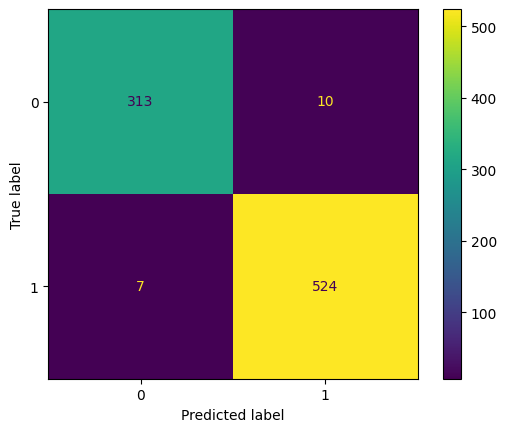

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()